# 01 Understanding Sequential Data and Time Series Prediction

## 📚 Learning Objectives

By completing this notebook, you will:
- **Understand** what sequential data is (order matters: time series, text, speech) and why we need models that use context (RNNs, Transformers)
- **Build** a **time series** dataset from a **real** log — daily 911 emergency-call volume for Montgomery County, Pennsylvania — and run a **baseline** that flattens the sequence (no RNN yet)
- **Measure** performance the honest way: against the cheap rules a domain expert would write in one line, not against a coin flip

## 🌍 Real life

**Where is this used?** Sequential data appears in **time series** (call volume, sensors, prices), **text** (sentences, documents), and **speech**. Order matters: "dog bites man" vs "man bites dog." Here we use a real emergency-dispatch log from Montgomery County, Pennsylvania. The full log holds 663,522 calls; **this notebook deliberately reads the 25,000-call sample that ships inside the repository**, so the numbers you see are the numbers written here, on any machine. It spans the same 1,692 consecutive days and keeps the same structure: a genuine weekly rhythm (Friday is the busiest weekday, Sunday the quietest), real storm spikes, and a real COVID-19 collapse in spring 2020 — structure an invented sine wave would not have.

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 4, lesson 06 "RNN, LSTM, and GRU for Sequential Data" — you met sequence models there; here we start further back, from why order matters at all.

---

**📌 Covers slide(s):** **21** — Understanding Sequential Data. *Do this notebook after that slide.*

**Next:** `02_rnn_basics.ipynb` introduces RNNs for actual sequences.

---


## Theory (short)

- **Sequential data:** Order matters (e.g. time steps, words in a sentence). Examples: time series (call volume, sensors, prices), text, speech.
- **Time series prediction:** We use **past values** in the sequence to predict the **next value** (or a label). Here we slide a window of length `seq_len` over the series and predict the next day.
- **Why not a plain MLP?** A feedforward network can take flattened sequences but treats each position as an independent column; it does not model "what came before." In **02_rnn_basics** we use **RNNs** that maintain a hidden state over time.
- **Never shuffle a time series.** Splitting at random would train on the future and test on the past. Every split in this notebook is chronological.
- **A forecast has no meaning on its own.** It is only good *relative to* the cheapest rule that would also have worked: yesterday's value, the same weekday last week, or the training mean. We report all of them.


## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, pandas, scikit-learn, PyTorch. **Real data, loaded with one call:** `load("montgomery_911_calls", prefer="sample")` — the emergency-call log of Montgomery County, PA, December 2015 to July 2020. There is no file path to edit: the loader finds the data from any working directory, and fetches what it needs on Google Colab.

**Which copy you get — and why it is pinned.** This notebook asks for the sample *on purpose*. `prefer="sample"` reads the 25,000-call file that ships inside the repository **even on a machine that also holds the full 123 MB log**, so a fresh clone, a Colab session and the instructor's laptop all print identical numbers. **Every number written into this notebook is therefore a number you can check against your own screen.**

The sample keeps 1 call in every 27, evenly spread through a file that is already in chronological order, so its daily series tracks the full one at **correlation 0.993** — the same 1,692 days, the same weekday ordering, the same busiest day (2 March 2018), the same 28% COVID-19 drop and the same ranking of the four models below — at about **1/26 of the height**. The real county averages **392 calls a day**; what this notebook reads averages **15**. If you have downloaded the original and want the true counts, change `prefer="sample"` to `prefer="full"`: every count and every error scales up by roughly 26×, and the conclusions do not move.

**Dataset:** We aggregate the raw call log into **one number per calendar day** (how many 911 calls arrived), giving 1,692 consecutive daily observations. A sliding window turns that series into (past 14 days → next day) pairs.

**Outputs:** Mean absolute error and RMSE for the next-day forecast, **side by side with three naive baselines**; then a direction-of-change classifier (LSTM) scored against a coin flip, the base rate, and a one-line weekday rule — with a significance test on the difference.

---


montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
Real series: 1692 consecutive days, 2015-12-11 to 2020-07-28
Calls per day: mean 15, min 5, max 83 (busiest day: 2018-03-02)
Mean calls by weekday: {'Mon': 15, 'Tue': 15, 'Wed': 15, 'Thu': 15, 'Fri': 16, 'Sat': 14, 'Sun': 12}

Train: 1342 days (up to 2019-08-27)   Test: 336 days (2019-08-28 to 2020-07-28)

Next-day forecast on the held-out period (lower is better):
model                                       MAE     RMSE
Ridge on 14 lags                           2.00     3.35
Naive: yesterday's count                   2.11     3.96
Naive: same weekday last week              2.22     4.36
Naive: training mean                

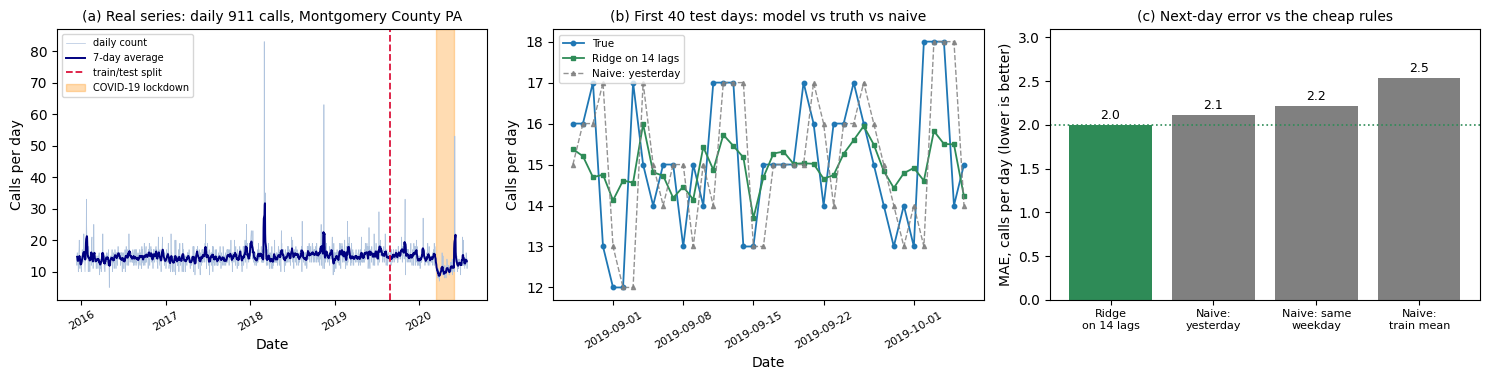

In [1]:
# WHAT: load a REAL time series - daily 911 emergency-call volume for Montgomery County, PA -
#       and predict tomorrow's call count from the past 14 days.
# WHY: sequential data only teaches you something when the order carries REAL structure.
#      This series has a genuine weekly rhythm, real storm spikes and a real COVID-19 drop;
#      an invented sine wave would have none of that.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/montgomery_911_calls.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # finds the call log from any working directory
# -------------------------------------------------------------------------------------

# 1) Load the real call log and count how many calls arrived on each calendar day.
#    We only need the timestamp column, so we skip the other 8 columns.
# WHY prefer="sample": we deliberately read the 25,000-call sample that ships INSIDE the
#    repository, even on a machine that also has the full 123 MB log. That way this notebook
#    prints the SAME numbers for everyone - your laptop, the instructor's, Google Colab - so
#    every figure quoted in the text below is one you can check against your own screen.
#    The sample keeps 1 call in every 27, evenly spread through a file that is already in
#    chronological order, so the daily series it produces tracks the full one almost exactly
#    (correlation 0.993) at about 1/26 of the height. Read the line load() prints: it says so.
#    Pass prefer="full" instead if you have downloaded the original and want the real counts.
stamps = pd.to_datetime(
    load("montgomery_911_calls", prefer="sample", usecols=["timeStamp"])["timeStamp"])
daily = stamps.dt.floor("D").value_counts().sort_index()
# The first and last calendar days are partial (logging starts mid-afternoon and stops
# mid-afternoon), so we drop them - otherwise two fake "quiet days" enter the series.
daily = daily.iloc[1:-1]

series = daily.to_numpy().astype(float)
dates = daily.index
print(f"Real series: {len(series)} consecutive days, {dates.min().date()} to {dates.max().date()}")
print(f"Calls per day: mean {series.mean():.0f}, min {series.min():.0f}, max {series.max():.0f} "
      f"(busiest day: {dates[series.argmax()].date()})")

# The weekly rhythm is real, not assumed - let the data state it.
by_dow = daily.groupby(daily.index.dayofweek).mean()
names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print("Mean calls by weekday:", {names[k]: round(v) for k, v in by_dow.items()})

# 2) Build sequences: the past `seq_len` days are the input, the next day is the target.
seq_len = 14  # two full weeks, so the model can see the weekly cycle twice
X = np.stack([series[i:i + seq_len] for i in range(len(series) - seq_len)])
y = series[seq_len:]
y_dates = dates[seq_len:]

# 3) Chronological split - NEVER shuffle a time series: training on the future and
#    testing on the past leaks information and inflates every score.
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"\nTrain: {len(X_train)} days (up to {y_dates[split - 1].date()})   "
      f"Test: {len(X_test)} days ({y_dates[split].date()} to {y_dates[-1].date()})")

# 4) Baseline model: flatten the 14-day window and fit a linear model.
#    It ignores order structure entirely - each lag is just another column.
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 5) Honest comparison. A forecast is only good RELATIVE to the cheap rules it must beat.
naive_yesterday = X_test[:, -1]        # "tomorrow looks like today"
naive_lastweek = X_test[:, -7]         # "tomorrow looks like the same weekday last week"
naive_mean = np.full_like(y_test, y_train.mean())  # "always predict the training average"

print("\nNext-day forecast on the held-out period (lower is better):")
print(f"{'model':38s} {'MAE':>8s} {'RMSE':>8s}")
scores = {}   # keep the MAEs so the figure below can show the same numbers as bars
for name, pred in [
    ("Ridge on 14 lags", y_pred),
    ("Naive: yesterday's count", naive_yesterday),
    ("Naive: same weekday last week", naive_lastweek),
    ("Naive: training mean", naive_mean),
]:
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    scores[name] = mae
    print(f"{name:38s} {mae:8.2f} {rmse:8.2f}")

# 6) Look at the same three claims instead of only reading them:
#    (a) the real series has spikes and a real COVID-19 collapse inside the test period;
#    (b) the Ridge forecast follows the weekly wiggle but flattens every peak;
#    (c) the error gap between the model and the cheap rules is small.
fig, axes = plt.subplots(1, 3, figsize=(15.0, 3.9))

# (a) the whole real series, with the split and the lockdown marked
axes[0].plot(dates, series, lw=0.5, color="lightsteelblue", label="daily count")
# A 7-day centred average: the daily line is too spiky to read a LEVEL off, and the
# level is exactly what changes in spring 2020.
axes[0].plot(dates, daily.rolling(7, center=True).mean(), lw=1.4, color="navy",
             label="7-day average")
axes[0].axvline(y_dates[split], color="crimson", ls="--", lw=1.3, label="train/test split")
axes[0].axvspan(pd.Timestamp("2020-03-15"), pd.Timestamp("2020-05-31"),
                color="darkorange", alpha=0.30, label="COVID-19 lockdown")
axes[0].set_title("(a) Real series: daily 911 calls, Montgomery County PA", fontsize=10)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Calls per day")
axes[0].legend(fontsize=7, loc="upper left")

# (b) a 40-day slice of the test period: truth, model, and the cheapest rule together
n_show = 40
sl = slice(split, split + n_show)
axes[1].plot(y_dates[sl], y_test[:n_show], "o-", ms=3.2, lw=1.3, color="#1f77b4", label="True")
axes[1].plot(y_dates[sl], y_pred[:n_show], "s-", ms=3.2, lw=1.3, color="seagreen", label="Ridge on 14 lags")
axes[1].plot(y_dates[sl], naive_yesterday[:n_show], "^--", ms=3.0, lw=1.0, color="grey",
             alpha=0.85, label="Naive: yesterday")
axes[1].set_title(f"(b) First {n_show} test days: model vs truth vs naive", fontsize=10)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Calls per day")
axes[1].legend(fontsize=7.5)

# (c) the honest scoreboard: the model bar next to the rules it has to beat
labels_b = ["Ridge\non 14 lags", "Naive:\nyesterday", "Naive: same\nweekday", "Naive:\ntrain mean"]
vals_b = [scores["Ridge on 14 lags"], scores["Naive: yesterday's count"],
          scores["Naive: same weekday last week"], scores["Naive: training mean"]]
bars = axes[2].bar(labels_b, vals_b, color=["seagreen", "grey", "grey", "grey"])
axes[2].bar_label(bars, fmt="%.1f", fontsize=9, padding=2)
axes[2].axhline(vals_b[0], color="seagreen", ls=":", lw=1.2)
axes[2].set_ylim(0, max(vals_b) * 1.22)
axes[2].set_title("(c) Next-day error vs the cheap rules", fontsize=10)
axes[2].set_ylabel("MAE, calls per day (lower is better)")
axes[2].tick_params(axis="x", labelsize=8)

for ax in axes[:2]:
    ax.tick_params(axis="x", rotation=30, labelsize=8)
plt.tight_layout()
plt.show()


### 👁️ Read the figure

- **(a)** The blue line is the raw series, one point per day. The tall thin spikes are real storm days (the highest, 83 calls, is 2 March 2018 — the same storm day the full log peaks on). The red dashed line is where training stops; everything to its right is unseen. The navy line is the 7-day average, which is what you read a *level* off. Inside the orange spring-2020 lockdown band that navy line drops to a visibly lower level than anywhere else in five years (about **10.6 calls/day against 14.6 in January–February 2020, a 28% fall**), so part of the test error below is a genuine distribution shift, not model weakness.
- **(b)** Blue is the truth, green is the Ridge forecast, grey dashed is "just repeat yesterday". Green follows the weekly up-and-down, but it is visibly *flatter*: across these 40 days the truth swings between **12 and 18** calls while the green forecast never leaves **13.7–16.0**. **The model shaves the extremes** — that is what a squared-error fit on a noisy series does. The grey dashed line is yesterday's count, and you can see it is simply the blue line shifted one day right.
- **(c)** The same four numbers as the table, on one axis so the size of the win is visible. The green bar is only a little shorter than the first grey bar. **The model beats "yesterday's count" by about 0.11 calls a day out of ~2.1** — about 5% better: a real improvement, and a small one.

### Building sequences: watch the window slide

Everything in this unit starts from one operation: slide a fixed-length window along the series, call what is inside it the **input** and the very next day the **target**, then move one day forward. The storyboard below freezes that sliding at four positions over the same stretch of real days.

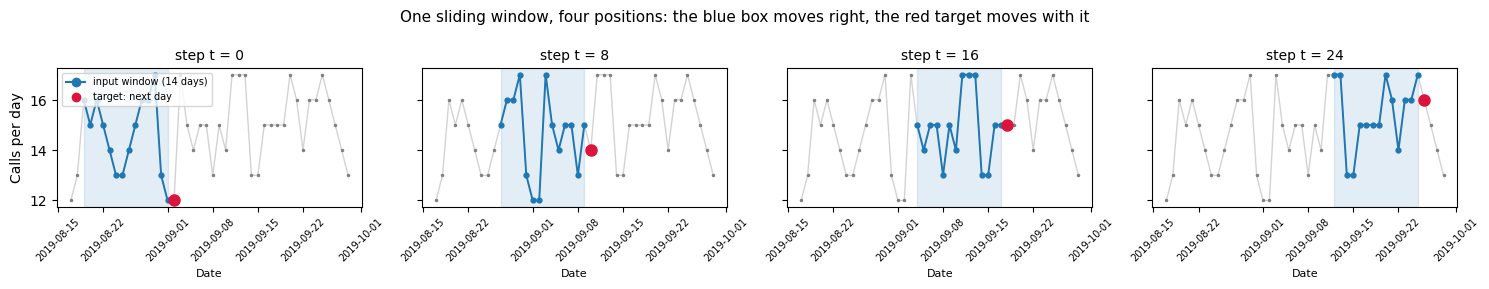

 step  window starts    window ends     target day  target calls
    0     2019-08-19     2019-09-01     2019-09-02            12
    8     2019-08-27     2019-09-09     2019-09-10            14
   16     2019-09-04     2019-09-17     2019-09-18            15
   24     2019-09-12     2019-09-25     2019-09-26            16

Each frame is one row of X and one entry of y. Sliding over the whole series gives 1,678 such pairs.


In [2]:
# WHAT: a 4-frame storyboard of the sliding window that turns one long series into (X, y) pairs.
# WHY:  every sequence model in this unit is fed by this one operation. Seeing the blue box
#       march to the right - and the red target dot march with it - makes the code above concrete.
#       Static frames, not an animation: a storyboard always renders, in every environment.
STRIDE = 8                          # days the window advances between frames
start0 = split + 5                  # start inside the (unseen) test period, on real data
view_lo = start0 - 2                # all four frames share ONE x-window and ONE y-range,
view_hi = start0 + seq_len + 3 * STRIDE + 4   # so the only thing that moves is the box

view_idx = np.arange(view_lo, view_hi)
view_vals = series[view_idx]
view_dates = dates[view_idx]

fig, axes = plt.subplots(1, 4, figsize=(15.0, 2.9), sharey=True)
rows = []
for f, ax in enumerate(axes):
    w0 = start0 + f * STRIDE            # first day inside the window
    w1 = w0 + seq_len                   # one past the last day inside the window
    ax.plot(view_dates, view_vals, "-", color="lightgrey", lw=1.0, zorder=1)
    ax.plot(view_dates, view_vals, ".", color="grey", ms=3, zorder=2)
    # the 14 days the model actually sees
    ax.plot(dates[w0:w1], series[w0:w1], "o-", color="#1f77b4", ms=3.5, lw=1.4, zorder=3)
    ax.axvspan(dates[w0], dates[w1 - 1], color="#1f77b4", alpha=0.13, zorder=0)
    # the single day it must predict
    ax.plot(dates[w1], series[w1], "o", color="crimson", ms=8, zorder=4)
    ax.set_title(f"step t = {f * STRIDE}", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.set_xlabel("Date", fontsize=8)
    rows.append((f * STRIDE, dates[w0].date(), dates[w1 - 1].date(), dates[w1].date(), series[w1]))

axes[0].set_ylabel("Calls per day")
axes[0].plot([], [], "o-", color="#1f77b4", label=f"input window ({seq_len} days)")
axes[0].plot([], [], "o", color="crimson", label="target: next day")
axes[0].legend(fontsize=7, loc="upper left")
fig.suptitle("One sliding window, four positions: the blue box moves right, the red target moves with it",
             fontsize=11)
plt.tight_layout()
plt.show()

# The same four frames as numbers, so nothing in the picture is taken on trust.
print(f"{'step':>5s}  {'window starts':>13s}  {'window ends':>13s}  {'target day':>13s}  {'target calls':>12s}")
for t, a, b, c, v in rows:
    print(f"{t:5d}  {str(a):>13s}  {str(b):>13s}  {str(c):>13s}  {v:12.0f}")
print(f"\nEach frame is one row of X and one entry of y. Sliding over the whole series gives "
      f"{len(X):,} such pairs.")

**What the storyboard proves:** the four panels plot the *same* stretch of real days (grey), so any difference between them is the window itself. From left to right the shaded blue box and its 14 blue points shift 8 days right each frame, and the red dot — the day being predicted — shifts with it. Nothing about the model changes between frames; only *which* 14 numbers it is shown. The printed table lists the exact dates and target values for the same four frames, so the picture and the numbers can be checked against each other.

## 🌍 Real-World Worked Example — Predicting Whether Tomorrow Is Busier (and an Honesty Check)

**Industry context:** Dispatch centres, ride-hailing platforms and hospital admissions teams all
run sequence models over call/demand volume to plan staffing. The headline number in those
projects is almost always quoted against a **coin flip** — and that comparison is the wrong one.

We train an **LSTM** to predict whether tomorrow will bring **more** 911 calls than today, from
the last 21 days of real call volume. Unlike an invented random walk, this series does contain a
real signal: the county's **weekly rhythm**. So the model *will* beat 50%. The question the rest
of the cell answers is the one that matters — does it beat the **one-line rule** that captures
that same weekly rhythm?

*Preview: this example uses an **LSTM**, which notebooks `02`–`03` introduce properly. Run it as a demo now and revisit the model code after `03_lstm_advanced`.*


Train 1336 days, test 335 days (2019-08-29 to 2020-07-28)



P(calls rise tomorrow) by weekday, measured on the training years:
   Mon 0.87  Tue 0.51  Wed 0.43  Thu 0.34  Fri 0.51  Sat 0.14  Sun 0.15

LSTM on 21 days of history:         71.9%
Coin flip (the number demos quote):  50.0%
Base rate (always guess majority):  63.0%  (test period is 37.0% 'up' days)
One-line weekday rule:              67.2%

LSTM edge over a coin flip:      +21.9 points  <- the flattering number
LSTM edge over the weekday rule:  +4.8 points  <- the honest number

McNemar: LSTM right & rule wrong on 73 days; rule right & LSTM wrong on 57 days.
Exact two-sided p = 0.19

HONEST READING: the weekly signal is REAL - you can see it in the table above, and both
predictors exploit it. But the LSTM's remaining edge over the one-line rule is NOT
statistically distinguishable from zero (p = 0.19). On this data, three weeks of
history plus 12,994 LSTM parameters buy no reliable improvement over 'what weekday is it?'.
Report it that way. The lesson is not that LSTMs are useless - 

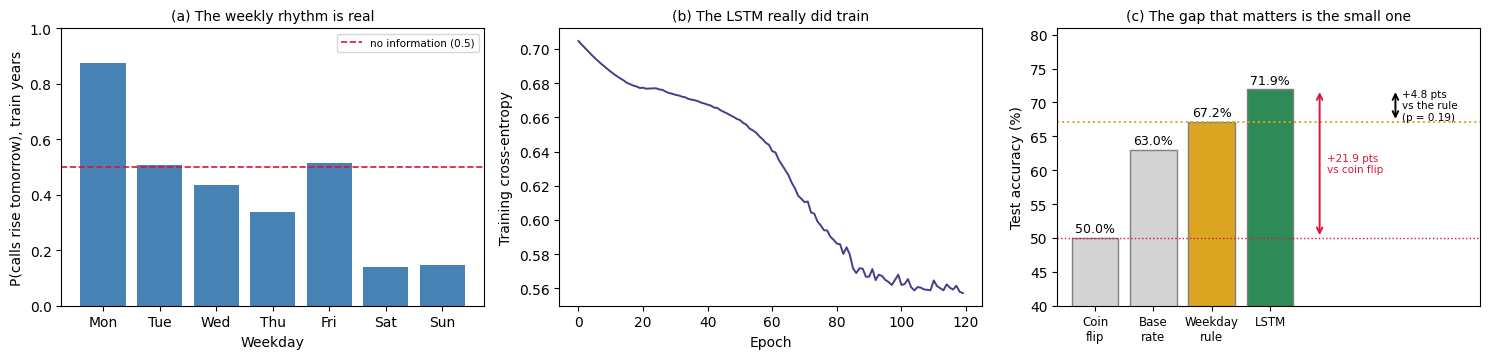

In [3]:
# WHAT: train an LSTM to predict the DIRECTION of tomorrow's 911 call volume (up or down),
#       then score it against the baselines an honest report would have to include.
# WHY: the gap above a coin flip is the flattering number. The gap above a rule a dispatcher
#      could write from memory is the honest one - and here they are very different.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import binomtest

torch.manual_seed(0)

# ── Real data: the same daily 911 call counts loaded above ──────────────────
SEQ_LEN = 21  # three weeks of history
seq_x = np.stack([series[i:i + SEQ_LEN] for i in range(len(series) - SEQ_LEN)]).astype(np.float32)
target = series[SEQ_LEN:]
# Label 1 = tomorrow has MORE calls than today, 0 = the same or fewer.
labels = (target > seq_x[:, -1]).astype(np.int64)
label_dates = dates[SEQ_LEN:]

# Normalise each window on its own mean/std so the model learns the SHAPE of the last
# three weeks rather than the absolute traffic level of that stretch of history.
seq_n = (seq_x - seq_x.mean(1, keepdims=True)) / (seq_x.std(1, keepdims=True) + 1e-8)

cut = int(0.8 * len(seq_n))  # chronological split again
Xtr = torch.tensor(seq_n[:cut]).unsqueeze(-1)          # (N, 21, 1)
Ytr = torch.tensor(labels[:cut])
Xte = torch.tensor(seq_n[cut:]).unsqueeze(-1)
Yte = torch.tensor(labels[cut:])
print(f"Train {len(Xtr)} days, test {len(Xte)} days "
      f"({label_dates[cut].date()} to {label_dates[-1].date()})")

# ── LSTM ────────────────────────────────────────────────────────────────────
class TrendLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True, num_layers=2, dropout=0.2)
        self.fc = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # classify from the last time step

model = TrendLSTM()
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses = []
for epoch in range(120):
    model.train()
    loss = loss_fn(model(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

model.eval()
with torch.no_grad():
    lstm_pred = model(Xte).argmax(1).numpy()
y_true = labels[cut:]
acc = (lstm_pred == y_true).mean()

# ── Baseline 1: always predict the majority class (the base rate) ───────────
p_up = y_true.mean()
base = max(p_up, 1.0 - p_up)

# ── Baseline 2: a one-line rule a dispatcher could write from memory ────────
# For each weekday, does call volume usually rise? Fit that on TRAIN only, apply to TEST.
dow = np.array([d.dayofweek for d in label_dates])
up_rate_by_dow = np.array([labels[:cut][dow[:cut] == k].mean() for k in range(7)])
rule_pred = (up_rate_by_dow[dow[cut:]] > 0.5).astype(np.int64)
rule_acc = (rule_pred == y_true).mean()

names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print("\nP(calls rise tomorrow) by weekday, measured on the training years:")
print("   " + "  ".join(f"{names[k]} {up_rate_by_dow[k]:.2f}" for k in range(7)))

print(f"\nLSTM on 21 days of history:         {acc * 100:.1f}%")
print(f"Coin flip (the number demos quote):  50.0%")
print(f"Base rate (always guess majority):  {base * 100:.1f}%  (test period is {p_up * 100:.1f}% 'up' days)")
print(f"One-line weekday rule:              {rule_acc * 100:.1f}%")
print(f"\nLSTM edge over a coin flip:      {(acc - 0.5) * 100:+.1f} points  <- the flattering number")
print(f"LSTM edge over the weekday rule:  {(acc - rule_acc) * 100:+.1f} points  <- the honest number")

# ── Is that remaining edge real? McNemar's test on the SAME test days ───────
# Count the days where exactly one of the two predictors was right.
lstm_only = int(((lstm_pred == y_true) & (rule_pred != y_true)).sum())
rule_only = int(((lstm_pred != y_true) & (rule_pred == y_true)).sum())
p_value = binomtest(lstm_only, lstm_only + rule_only, 0.5).pvalue
print(f"\nMcNemar: LSTM right & rule wrong on {lstm_only} days; rule right & LSTM wrong on {rule_only} days.")
print(f"Exact two-sided p = {p_value:.2f}")
print("\nHONEST READING: the weekly signal is REAL - you can see it in the table above, and both")
print("predictors exploit it. But the LSTM's remaining edge over the one-line rule is NOT")
n_params = sum(p.numel() for p in model.parameters())
print(f"statistically distinguishable from zero (p = {p_value:.2f}). On this data, three weeks of")
print(f"history plus {n_params:,} LSTM parameters buy no reliable improvement over 'what weekday is it?'.")
print("Report it that way. The lesson is not that LSTMs are useless - it is that the baseline you")
print("choose decides whether your result reads as a breakthrough or as a rounding error.")

# Three panels, three steps of the argument: the rhythm is real -> the LSTM did train ->
# and once the rhythm is priced in, the LSTM's remaining edge is small.
fig, axes = plt.subplots(1, 3, figsize=(15.0, 3.7))

axes[0].bar(names, up_rate_by_dow, color="steelblue")
axes[0].axhline(0.5, color="crimson", ls="--", lw=1.2, label="no information (0.5)")
axes[0].set_title("(a) The weekly rhythm is real", fontsize=10)
axes[0].set_xlabel("Weekday")
axes[0].set_ylabel("P(calls rise tomorrow), train years")
axes[0].set_ylim(0, 1.0)
axes[0].legend(fontsize=7.5)

axes[1].plot(losses, color="darkslateblue", lw=1.4)
axes[1].set_title("(b) The LSTM really did train", fontsize=10)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Training cross-entropy")

acc_labels = ["Coin\nflip", "Base\nrate", "Weekday\nrule", "LSTM"]   # short: the bars are narrow
acc_vals = [50.0, base * 100, rule_acc * 100, acc * 100]
colours = ["lightgrey", "lightgrey", "goldenrod", "seagreen"]
bars = axes[2].bar(acc_labels, acc_vals, color=colours, edgecolor="grey")
axes[2].bar_label(bars, fmt="%.1f%%", fontsize=9, padding=2)
axes[2].axhline(rule_acc * 100, color="goldenrod", ls=":", lw=1.4)
axes[2].set_ylim(40, max(acc_vals) + 9)
axes[2].set_title("(c) The gap that matters is the small one", fontsize=10)
axes[2].set_ylabel("Test accuracy (%)")
axes[2].tick_params(axis="x", labelsize=8.5)
# Label both gaps in the clear margin to the RIGHT of the bars, so no text sits on a bar.
# Dotted guide lines carry the two reference levels across to the arrows.
axes[2].axhline(50.0, color="crimson", ls=":", lw=1.0)
axes[2].annotate("", xy=(3.85, acc * 100), xytext=(3.85, 50.0),
                 arrowprops=dict(arrowstyle="<->", color="crimson", lw=1.4))
axes[2].text(3.97, (acc * 100 + 50.0) / 2, f"+{(acc - 0.5) * 100:.1f} pts\nvs coin flip",
             fontsize=7.5, ha="left", va="center", color="crimson")
axes[2].annotate("", xy=(5.15, acc * 100), xytext=(5.15, rule_acc * 100),
                 arrowprops=dict(arrowstyle="<->", color="black", lw=1.4))
axes[2].text(5.27, (acc * 100 + rule_acc * 100) / 2,
             f"+{(acc - rule_acc) * 100:.1f} pts\nvs the rule\n(p = {p_value:.2f})",
             fontsize=7.5, ha="left", va="center")
axes[2].set_xlim(-0.65, 6.6)

plt.tight_layout()
plt.show()

### 👁️ Read the figure

- **(a)** Measured on the training years only: after a Monday, calls rise 87% of the time; after a Saturday, 14%. Monday (0.87), Saturday (0.14) and Sunday (0.15) sit far from the red 0.5 line, so **the weekly signal is real** — no model needed to see it.
- **(b)** The training loss falls from about 0.71 to about 0.56 and flattens. The LSTM is not broken and is not stuck; whatever it learned, it learned.
- **(c)** The punchline on one axis. The red arrow is the gap a demo would quote (**LSTM vs a coin flip**). The black arrow is the gap that survives once the weekday rule — the golden bar, which a dispatcher could write from memory — is taken as the baseline. The red arrow is long, the black arrow is short, and McNemar's test on those same 335 days cannot tell the black one from zero. *(Note the y-axis starts at 40%, not 0 — it is drawn that way so the two gaps are legible; compare the printed numbers, not the bar heights.)*

## Summary

**What you did:** (1) Turned a **real** emergency-call log — the repository's 25,000-call sample of it — into a daily time series (1,692 consecutive days). (2) Built sliding-window sequences (past 14 days → next day). (3) Trained a Ridge baseline on the flattened window and scored it against three naive rules. (4) Trained an LSTM to predict the direction of change and scored it against a coin flip, the base rate, and a one-line weekday rule.

**What actually happened — read the numbers, not the hype:**
- The Ridge model on 14 lags reached **MAE ≈ 2.00 calls/day**, versus **2.11** for "yesterday's count" and **2.22** for "same weekday last week." A real improvement, but a small one — about **5%** better than doing nothing clever. (Those are counts in the repository's 1-in-27 sample; on the full log the same three numbers are ≈ 52.1, 54.5 and 57.8, and the 5% gap is unchanged.)
- The LSTM direction classifier reached **71.9%**, which looks like **+21.9 points over a coin flip**. Against the one-line weekday rule (**67.2%**) the edge shrinks to **+4.8 points**, and McNemar's test on the same 335 test days gives **p ≈ 0.19** — i.e. not distinguishable from zero.
- The held-out period runs from August 2019 to July 2020, so it contains the **COVID-19 collapse** (call volume fell about 28% between mid-March and end of May 2020). Part of every model's test error here is a genuine distribution shift, not model weakness. Real series do this; sine waves do not.

**In real life you'd also:** Add calendar features (holiday, month), model the COVID break explicitly, and evaluate with rolling-origin cross-validation rather than one split.

**The main idea:** Order carries real structure — and *most of the exploitable structure in a real series is usually cheap to capture*. Always publish the naive baselines next to the model.

**Next:** `02_rnn_basics.ipynb` introduces RNNs for sequences.


## 📚 References

1. Elman, J. L. (1990). *Finding Structure in Time*. Cognitive Science 14(2), 179-211. https://doi.org/10.1207/s15516709cog1402_1
2. Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation 9(8), 1735-1780. https://doi.org/10.1162/neco.1997.9.8.1735
3. Lim, B. & Zohren, S. (2021). *Time-Series Forecasting With Deep Learning: A Survey*. Philosophical Transactions of the Royal Society A. https://arxiv.org/abs/2004.13408
4. Makridakis, S., Spiliotis, E. & Assimakopoulos, V. (2018). *Statistical and Machine Learning Forecasting Methods: Concerns and Ways Forward*. PLoS ONE 13(3): e0194889. https://doi.org/10.1371/journal.pone.0194889 — the large-scale study showing ML forecasters routinely losing to simple statistical baselines, which is exactly what the naive-baseline table above is guarding against.
5. Hyndman, R. J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.), Ch. 5.2 "Some simple forecasting methods". https://otexts.com/fpp3/simple-methods.html — definitions of the naive and seasonal-naive benchmarks used here.

**Data source:** Montgomery County, Pennsylvania 911 emergency-call log, 2015-2020, 663,522 calls in the original — read here as the 25,000-call sample that ships with the repository, via `load("montgomery_911_calls", prefer="sample")` so that every machine prints the same numbers; see `Course 04/datasets/DATA.md` for the original (Kaggle `mchirico/montcoalert`) and for how that sample is drawn. Published as an open dataset; used here unmodified apart from aggregating to daily counts.

**Recent work (2024–2026)**

6. Ansari et al. (2025). *Chronos-2: From Univariate to Universal Forecasting*. arXiv. https://arxiv.org/abs/2510.15821 — zero-shot forecasting from a pretrained model, now covering univariate, multivariate and covariate-informed settings. Note honestly: it requires downloading model weights and will not run in an offline classroom.
7. Aksu et al. (2024). *GIFT-Eval: A Benchmark For General Time Series Forecasting Model Evaluation*. arXiv. https://arxiv.org/abs/2410.10393 — the shared benchmark that makes zero-shot forecasting claims comparable across papers — the same discipline as the naive-baseline table above, at research scale.
